In [1]:
import torch
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
spectra = torch.load("spectra.pt")

# df = pd.DataFrame(
#     [(Xs.min().item(), Xs.max().item(), Ys.min().item(), Ys.max().item()) for Xs, Ys in spectra],
#     columns=["Xmin", "Xmax", "Ymin", "Ymax"]
# )
df = pd.DataFrame([(x.item(), y.item()) for (Xs, Ys) in spectra for (x, y) in zip(Xs, reversed(Ys))], columns=["Xs", "Ys"])

In [3]:
df["Xs^2"] = df["Xs"] ** 2
df["Y / X^2"] = df["Ys"] / df["Xs^2"]
df.head()

,Xs,Ys,Xs^2,Y / X^2
0,0.997239,0.994497,0.994486,1.000011
1,0.060291,0.003632,0.003635,0.999213
2,0.013383,0.000259,0.000179,1.444340
3,0.007149,0.000235,0.000051,4.595106
4,0.006621,0.000226,0.000044,5.147459


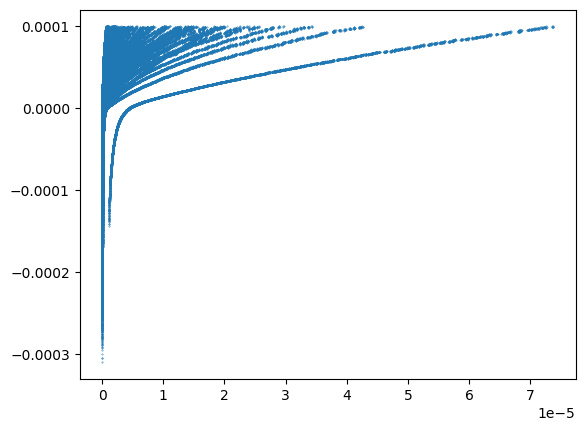

In [5]:
neg = df[df["Ys"] < 1e-4]
plt.scatter(neg["Xs^2"], neg["Ys"], s=0.1)
# plt.yscale("log")
# plt.xscale("log")

In [8]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

intermediate = torch.load("intermediate_alt2.pt")
R_list = intermediate["R"]

# precompute global limits
xlen = max(r.numel() for r in R_list)
ymin = min(r.min().item() for r in R_list)
ymax = max(r.max().item() for r in R_list)

fig, ax = plt.subplots(figsize=(8, 4))

def update(frame):
    ax.clear()
    for i, r in enumerate(R_list[: frame + 1]):
        y = r.cpu().numpy()
        y = -y  # plot the negatives
        x = np.arange(y.size)
        ax.plot(x, y, label=f"Iter {i}")
    ax.set_xlim(0, xlen - 1)
    # set yscale only if all values positive
    if True:  # ymin > 0:
        ax.set_yscale("log")
    ax.set_ylim(ymin, ymax)
    ax.legend(loc="upper left", fontsize="small")
    ax.set_title(f"Added up to iter {frame}")
    ax.grid(True)
    return ax.lines

anim = FuncAnimation(fig, update, frames=len(R_list), interval=300, blit=False)
plt.close(fig)  # prevent static display of the last frame
HTML(anim.to_jshtml())

/tmp/ipykernel_610420/1173885982.py:25: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")
/tmp/ipykernel_610420/1173885982.py:26: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ymin, ymax)
